# TAHAP 0.6 — Uji P1, P1b, dan P4 (baseline v2)

Menjalankan file uji parsial **revisi** (Total Malam Menginap memakai data aktual):

- **P1** — `Uji_Parsial_P1_P4_V2.mdl`, target **Jumlah Hotel dan Akomodasi**; TPK dievaluasi saja
- **P1b** — `UJI_Parsial_P1b_v2.mdl`, sama dengan P1 tetapi Rata-rata Kamar per Unit memakai data aktual (uji kekokohan penentu)
- **P4** — file yang sama dengan P1, target **Lahan Terbangun**

Statistik Barlas (1989) dihitung dalam tiga versi periode:

| Versi | Tahun | Kegunaan |
|---|---|---|
| Dengan COVID | 2016–2025 | pelaporan |
| Tanpa COVID | tanpa 2020–2021 | pelaporan |
| Periode objektif | P1: 2016–2019 + 2023–2025; P4: 2016–2019 + 2022–2025 | dasar kalibrasi Tahap 1 dan 2 |

Kolom **NRMSE** adalah fungsi tujuan kalibrasi: RMSE dibagi rata-rata data pada periode yang sama.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install pysd openpyxl matplotlib scipy -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.1/95.1 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 717.0/717.0 kB 13.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.2/150.2 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 919.5/919.5 kB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.4/268.4 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 11.1 MB/s eta 0:00:00


In [3]:
import warnings
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, pysd
from scipy import stats
warnings.filterwarnings("ignore")

FOLDER = Path("/content/drive/MyDrive/Skripsi_Citra/Pengujian Model Sistem Dinamis/[02] Uji Perilaku/Kalibrasi")
FILE_P1  = FOLDER / "Uji Parsial P1 & P4 V2.mdl"
FILE_P1B = FOLDER / "UJI Parsial P1b v2.mdl"
FOLDER.mkdir(parents=True, exist_ok=True)

for f in (FILE_P1, FILE_P1B):
    if not f.exists():
        from google.colab import files
        print(f"'{f.name}' belum ada, silakan upload:")
        files.upload()

## Data pembanding 2016–2025 (Master Data, sheet *Data Tahunan*)

In [4]:
TAHUN = np.arange(2016, 2026)
DATA = pd.DataFrame({
    "Jumlah Hotel dan Akomodasi": [1170,1179,1617,1817,1848,1696,1818,1820,2000,2291],
    "TPK": [0.3772,0.4508,0.4511,0.4534,0.2890,0.2748,0.4499,0.4477,0.4217,0.3807],
    "Lahan Terbangun": [44561.0784555117,50223.957001398,56624.3602289948,63480.0442236269,
                        58962.0411105434,59887.5260314565,57709.075808398,75624.403529316,
                        73511.574651116,55029.5352961885],
}, index=TAHUN)
DATA

,Jumlah Hotel dan Akomodasi,TPK,Lahan Terbangun
2016,1170,0.3772,44561.078456
2017,1179,0.4508,50223.957001
2018,1617,0.4511,56624.360229
2019,1817,0.4534,63480.044224
2020,1848,0.2890,58962.041111
2021,1696,0.2748,59887.526031
2022,1818,0.4499,57709.075808
2023,1820,0.4477,75624.403529
2024,2000,0.4217,73511.574651
2025,2291,0.3807,55029.535296


## Fungsi statistik dan penilaian

In [5]:
def statistik(sim, act, t):
    sim, act, t = np.asarray(sim,float), np.asarray(act,float), np.asarray(t,float)
    e = sim - act
    SA, SS, SE = act.std(), sim.std(), e.std()      # STDEV.P
    r = np.corrcoef(sim, act)[0,1]; mse = np.mean(e**2)
    la, ls = stats.linregress(t, act), stats.linregress(t, sim); n = len(t)
    t_hit = abs(ls.slope - la.slope) / np.sqrt(la.stderr**2 + ls.stderr**2)
    t_tab = stats.t.ppf(0.975, 2*n - 4)
    tren = ("Berlawanan arah" if np.sign(ls.slope) != np.sign(la.slope)
            else ("Berbeda nyata" if t_hit > t_tab else "Tidak berbeda nyata"))
    return {"n":n, "Kemiringan data":la.slope, "Kemiringan simulasi":ls.slope,
            "t hitung":t_hit, "t tabel":t_tab, "Tren":tren,
            "E1":abs(sim.mean()-act.mean())/abs(act.mean()), "E2":abs(SS-SA)/SA,
            "DC":SE/(SA+SS), "r":r,
            "U1":(sim.mean()-act.mean())**2/mse, "U2":(SS-SA)**2/mse, "U3":2*(1-r)*SS*SA/mse,
            "MAPE (%)":100*np.mean(np.abs(e/act))}


def penilaian(t):
    t = t.copy()
    t["Arah kemiringan"] = np.where(np.sign(t["Kemiringan simulasi"]) == np.sign(t["Kemiringan data"]),
                                    "Searah", "Berlawanan")
    lolos = t["Tren"] == "Tidak berbeda nyata"
    t["Status Tren"] = np.where(lolos, "Lolos", "Tidak lolos")
    t["Status E1 (<=0,05)"] = np.where(~lolos, "Tidak ditafsirkan", np.where(t["E1"] <= 0.05, "Lolos", "Tidak lolos"))
    t["Status E2 (<=0,30)"] = np.where(~lolos, "Tidak ditafsirkan", np.where(t["E2"] <= 0.30, "Lolos", "Tidak lolos"))
    t["Kategori DC"] = np.where(t["DC"] < 0.4, "Baik", np.where(t["DC"] <= 0.7, "Cukup", "Kurang"))
    t["Komponen dominan"] = t[["U1","U2","U3"]].idxmax(axis=1).map(
        {"U1":"U1 (bias)", "U2":"U2 (variasi)", "U3":"U3 (kovariasi)"})
    return t[["Uji","Variabel","Versi","Arah kemiringan","t hitung","t tabel","Tren","Status Tren","E1",
              "Status E1 (<=0,05)","E2","Status E2 (<=0,30)","DC","Kategori DC","U1","U2","U3",
              "Komponen dominan","MAPE (%)","r","n","Kemiringan data","Kemiringan simulasi"]]


def jalankan(berkas):
    m = pysd.read_vensim(str(berkas))
    tpk = [k for k in m.namespace if "TPK" in k and "Ambang" not in k][0]
    kol = ["Jumlah Hotel dan Akomodasi", tpk, "Lahan Terbangun",
           "Rasio Permintaan terhadap Kapasitas Kamar", "Laju Konstruksi Hotel dan Akomodasi",
           "Laju Demolisi Hotel dan Akomodasi", "Total Malam Menginap"]
    r = m.run(return_columns=kol, return_timestamps=list(TAHUN)).apply(lambda s: np.real(s.astype(complex)))
    return r.rename(columns={tpk: "TPK"})

## Jalankan simulasi

In [6]:
sim = {"P1": jalankan(FILE_P1), "P1b": jalankan(FILE_P1B)}
sim["P4"] = sim["P1"]        # P4 memakai file yang sama; targetnya Lahan Terbangun

print("Cek P1  — Hotel 2025:", f"{sim['P1']['Jumlah Hotel dan Akomodasi'][2025]:,.3f}", "(harus ≈ 2.192,585)")
print("Cek P1b — Hotel 2025:", f"{sim['P1b']['Jumlah Hotel dan Akomodasi'][2025]:,.3f}", "(harus ≈ 2.152,072)")
sim["P1"].round(3)

Cek P1  — Hotel 2025: 2,192.585 (harus ≈ 2.192,585)
Cek P1b — Hotel 2025: 2,152.072 (harus ≈ 2.152,072)


,Jumlah Hotel dan Akomodasi,TPK,Lahan Terbangun,Rasio Permintaan terhadap Kapasitas Kamar,Laju Konstruksi Hotel dan Akomodasi,Laju Demolisi Hotel dan Akomodasi,Total Malam Menginap
time,,,,,,,
2016,1170.000,0.357,44561.100,0.357,71.162,58.500,6097320.0
2017,1182.662,0.632,46243.351,0.632,136.556,59.133,10899900.0
2018,1260.085,0.560,47983.496,0.560,374.797,63.004,10293300.0
2019,1571.878,0.583,49803.495,0.583,528.141,78.594,13363900.0
2020,2021.425,0.161,51694.646,0.161,0.000,101.071,4753100.0
2021,1920.354,0.263,53586.604,0.263,0.000,96.018,7379580.0
2022,1824.336,0.348,55535.527,0.348,78.568,91.217,9267220.0
2023,1811.687,0.432,57545.947,0.432,427.081,90.584,11417700.0
2024,2148.183,0.367,59650.888,0.367,151.811,107.409,11503500.0


## Hitung statistik tiga versi periode

In [7]:
TARGET = {"P1": ["Jumlah Hotel dan Akomodasi", "TPK"],
          "P1b": ["Jumlah Hotel dan Akomodasi", "TPK"],
          "P4": ["Lahan Terbangun"]}
PERIODE = {"P1":  [2016,2017,2018,2019,2023,2024,2025],
           "P1b": [2016,2017,2018,2019,2023,2024,2025],
           "P4":  [2016,2017,2018,2019,2022,2023,2024,2025]}

hasil, seri = [], {}
for uji, r in sim.items():
    for v in TARGET[uji]:
        act_all, s_all = DATA[v].values, r[v].values
        seri[f"{uji} {v}"] = pd.DataFrame({"Tahun":TAHUN, "Data":act_all, "Simulasi":s_all})
        for nama, th in [("Dengan COVID", TAHUN),
                         ("Tanpa COVID", TAHUN[~np.isin(TAHUN,[2020,2021])]),
                         ("Periode objektif", np.array(PERIODE[uji]))]:
            msk = np.isin(TAHUN, th)
            nrmse = np.sqrt(np.mean((s_all[msk]-act_all[msk])**2)) / act_all[msk].mean()
            hasil.append({"Uji":uji, "Variabel":v, "Versi":nama,
                          **statistik(s_all[msk], act_all[msk], TAHUN[msk]), "NRMSE":nrmse})

tabel = pd.DataFrame(hasil)
nrmse = tabel.pop("NRMSE")
tabel = penilaian(tabel); tabel["NRMSE"] = nrmse.values
tabel[["Uji","Variabel","Versi","Status Tren","E1","Status E1 (<=0,05)","E2","Status E2 (<=0,30)",
       "DC","Kategori DC","Komponen dominan","NRMSE"]].round(4)

,Uji,Variabel,Versi,Status Tren,E1,"Status E1 (<=0,05)",E2,"Status E2 (<=0,30)",DC,Kategori DC,Komponen dominan,NRMSE
0,P1,Jumlah Hotel dan Akomodasi,Dengan COVID,Lolos,0.0089,Lolos,0.1435,Lolos,0.2476,Baik,U3 (kovariasi),0.1003
1,P1,Jumlah Hotel dan Akomodasi,Tanpa COVID,Lolos,0.0402,Lolos,0.0773,Lolos,0.2011,Baik,U3 (kovariasi),0.0966
2,P1,Jumlah Hotel dan Akomodasi,Periode objektif,Lolos,0.0468,Lolos,0.0672,Lolos,0.1997,Baik,U3 (kovariasi),0.1041
3,P1,TPK,Dengan COVID,Lolos,0.0204,Lolos,1.1513,Tidak lolos,0.4667,Cukup,U2 (variasi),0.2398
4,P1,TPK,Tanpa COVID,Lolos,0.0643,Tidak lolos,2.5684,Tidak lolos,0.6692,Cukup,U2 (variasi),0.2263
5,P1,TPK,Periode objektif,Lolos,0.1081,Tidak lolos,2.4214,Tidak lolos,0.6094,Cukup,U2 (variasi),0.2263
6,P1b,Jumlah Hotel dan Akomodasi,Dengan COVID,Lolos,0.0200,Lolos,0.2128,Lolos,0.2868,Baik,U3 (kovariasi),0.1212
7,P1b,Jumlah Hotel dan Akomodasi,Tanpa COVID,Lolos,0.0182,Lolos,0.1223,Lolos,0.2319,Baik,U3 (kovariasi),0.1051
8,P1b,Jumlah Hotel dan Akomodasi,Periode objektif,Lolos,0.0291,Lolos,0.1020,Lolos,0.2265,Baik,U3 (kovariasi),0.1112
9,P1b,TPK,Dengan COVID,Lolos,0.0193,Lolos,1.2416,Tidak lolos,0.4985,Cukup,U2 (variasi),0.2633


## Simpan Excel dan grafik

Tersimpan: /content/drive/MyDrive/Skripsi_Citra/Pengujian Model Sistem Dinamis/[02] Uji Perilaku/Kalibrasi/hasil_P1_P4_baseline_v2.xlsx


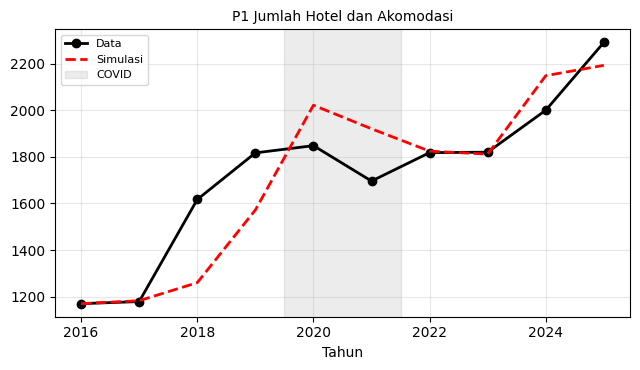

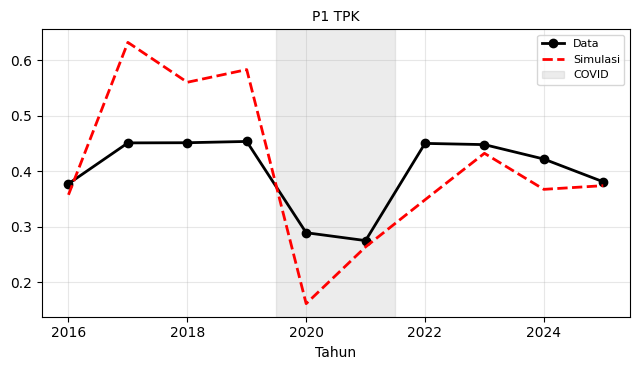

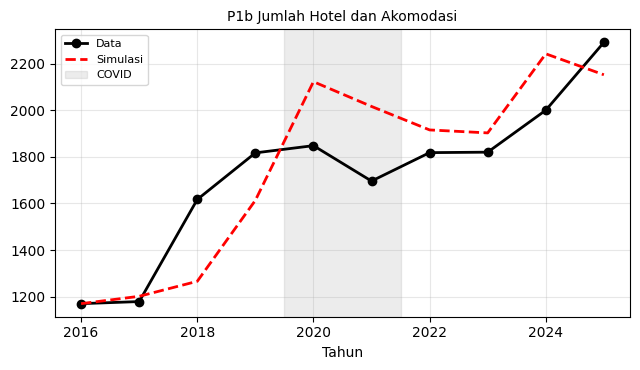

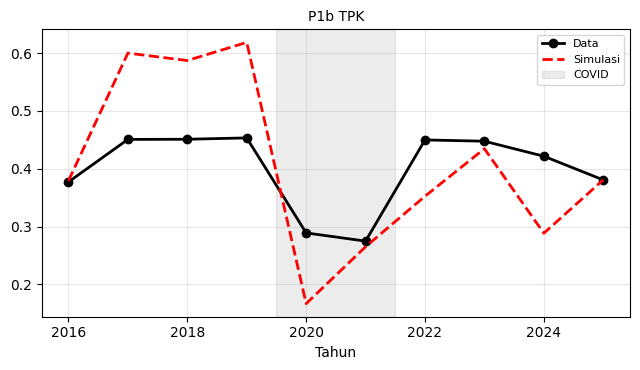

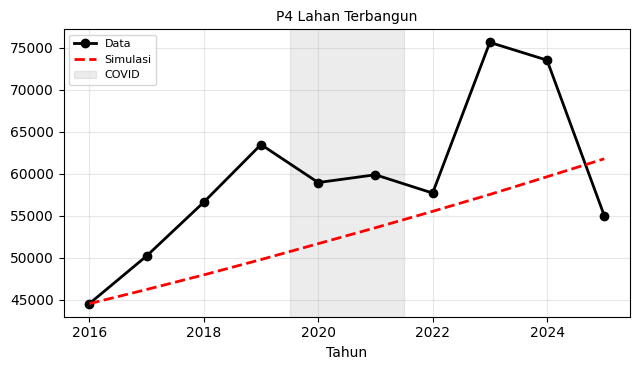

In [8]:
berkas = FOLDER / "hasil_P1_P4_baseline_v2.xlsx"
with pd.ExcelWriter(berkas) as w:
    tabel.round(6).to_excel(w, sheet_name="Statistik", index=False)
    sim["P1"].round(4).to_excel(w, sheet_name="P1 P4 simulasi")
    sim["P1b"].round(4).to_excel(w, sheet_name="P1b simulasi")
    DATA.round(4).to_excel(w, sheet_name="Data Pembanding")
    for nama, df in seri.items():
        df.round(4).to_excel(w, sheet_name=nama[:31], index=False)
print("Tersimpan:", berkas)

for nama, df in seri.items():
    fig, ax = plt.subplots(figsize=(6.5, 3.8))
    ax.plot(df["Tahun"], df["Data"], "ko-", lw=2, label="Data")
    ax.plot(df["Tahun"], df["Simulasi"], "r--", lw=2, label="Simulasi")
    ax.axvspan(2019.5, 2021.5, color="grey", alpha=0.15, label="COVID")
    ax.set_title(nama, fontsize=10); ax.set_xlabel("Tahun")
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
    fig.tight_layout(); fig.savefig(FOLDER / f"baseline_v2_{nama.replace(' ','_')}.png", dpi=150)
    plt.show(); plt.close(fig)

## Angka untuk pencocokan

**P1 Jumlah Hotel:** DC 0,2476 / 0,2011 / 0,1997 (Baik pada ketiga versi); tren lolos; E1 0,0089 / 0,0402 / 0,0468 (lolos); E2 0,1435 / 0,0773 / 0,0672 (lolos); NRMSE periode objektif **0,1041**.

**P1b Jumlah Hotel:** DC 0,2868 / 0,2319 / 0,2265; NRMSE periode objektif **0,1112**.

**P1 TPK:** DC 0,4667 / 0,6692 / 0,6094; E2 tidak lolos (U2 dominan) karena derau data Total Malam.

**P4 Lahan Terbangun:** DC 0,4809 / 0,4813 / 0,4813; NRMSE periode objektif **0,1726**.